<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/Data_collection_EDA_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np


In [61]:


# 1. Merging 7 yearly NSE files (2000-2006) from NIFTY 50

pre2007_files = glob.glob("/content/*.csv")

pre2007_dfs = []
required_cols = ['Open', 'High', 'Low', 'Close']
volume_col_names = ['Volume', 'Shares Traded']

for file in pre2007_files:
    try:
        df_year = pd.read_csv(file)


        df_year.columns = df_year.columns.str.strip().str.title()

        # Finding the date column
        date_col = None
        for col in df_year.columns:
            if 'Date' in col:
                date_col = col
                break

        if date_col:
            df_year['Date'] = pd.to_datetime(df_year[date_col])
            df_year.set_index('Date', inplace=True)


            temp_df = df_year[required_cols].copy()

            # Handling volume column
            found_volume_col = None
            for vol_col in volume_col_names:
                if vol_col.title() in df_year.columns:
                    found_volume_col = vol_col.title()
                    break

            if found_volume_col:
                temp_df['Volume'] = df_year[found_volume_col]
            else:
                temp_df['Volume'] = 0


            temp_df['Adj Close'] = np.nan

            pre2007_dfs.append(temp_df)
        else:
            print(f"Warning: Date column not found in {file}. Skipping this file. Available columns: {df_year.columns.tolist()}")
    except Exception as e:
        print(f"Error processing file {file}: {e}. Skipping.")

# Concatenating all pre-2007 years
if pre2007_dfs:
    pre2007 = pd.concat(pre2007_dfs).sort_index()
    # Removing duplicate dates if any exist after concatenation
    pre2007 = pre2007.loc[~pre2007.index.duplicated(keep='first')]
else:
    print("No valid pre-2007 dataframes were processed.")
    pre2007 = pd.DataFrame(columns=required_cols + ['Volume', 'Adj Close']) # Initialize with expected columns

# 2. existing yfinance data (2007-2026)
yf_data = yf.download('^NSEI', start='2007-01-01', end='2026-03-04', auto_adjust=False)
yf_data.columns = yf_data.columns.droplevel(1)  # Flattening multi-index
yf_data.index.name = 'Date'

# Standardizing yfinance columns to match the target columns if needed
yf_data_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
yf_data = yf_data[yf_data_cols]



if not pre2007.empty:

    pre2007 = pre2007[pre2007.index < yf_data.index.min()]
    full_nifty = pd.concat([pre2007, yf_data]).sort_index().drop_duplicates()
else:
    full_nifty = yf_data.copy()


full_nifty.dropna(subset=['Close'], inplace=True)

# Final check of column names and order
final_columns_order = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
full_nifty = full_nifty[final_columns_order]


print(f"Full dataset: {len(full_nifty)} days ({full_nifty.index[0].year}-{full_nifty.index[-1].year})")
print(full_nifty.head())
print(full_nifty.tail())

# Save complete 25+ year dataset
full_nifty.to_csv('nifty_25years_complete.csv')

/tmp/ipykernel_563/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_563/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_563/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_year['Date'] = pd.to_datetime(df_year[date_col])
/tmp/ipykernel_563/807103263.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent 

Full dataset: 6287 days (1999-2026)
              Open    High     Low   Close    Volume  Adj Close
Date                                                           
1999-01-01  886.75  892.20  882.60  890.80  31356585        NaN
1999-01-04  896.40  905.45  895.75  897.80  32224833        NaN
1999-01-05  901.00  907.20  893.15  907.20  36723940        NaN
1999-01-06  923.30  930.55  915.65  928.25  43232321        NaN
1999-01-07  932.95  961.15  932.95  954.70  65480034        NaN
                    Open          High           Low         Close  Volume  \
Date                                                                         
2026-02-24  25641.800781  25641.800781  25327.599609  25424.650391  439100   
2026-02-25  25512.599609  25652.599609  25428.199219  25482.500000  414200   
2026-02-26  25556.300781  25572.949219  25400.949219  25496.550781  405200   
2026-02-27  25459.849609  25476.400391  25141.300781  25178.650391  438900   
2026-03-02  24659.250000  24989.349609  24603.50

In [62]:
full_nifty_df = pd.read_csv('nifty_25years_complete.csv', index_col='Date', parse_dates=True)
full_nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6287 entries, 1999-01-01 to 2026-03-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       6287 non-null   float64
 1   High       6287 non-null   float64
 2   Low        6287 non-null   float64
 3   Close      6287 non-null   float64
 4   Volume     6287 non-null   int64  
 5   Adj Close  4528 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 343.8 KB


* Dropping adj close for ML model building

In [63]:

full_nifty_df = full_nifty_df[['Open', 'High', 'Low', 'Close', 'Volume']]


yearly = full_nifty_df.groupby(full_nifty_df.index.year).agg({
    'Open': 'first',
    'Close': 'last',
    'High': 'max',
    'Low': 'min',
    'Volume': 'mean'
}).reset_index()

print(yearly.head(10))


   Date         Open        Close         High          Low        Volume
0  1999   886.750000  1480.450000  1522.850000   882.600000  3.934727e+07
1  2000  1482.150000  1263.550000  1818.150000  1108.200000  4.524447e+07
2  2001  1263.500000  1059.050000  1422.950000   849.950000  5.388264e+07
3  2002  1058.850000  1093.500000  1205.950000   920.100000  5.063023e+07
4  2003  1093.600000  1879.750000  1914.400000   920.000000  9.180550e+07
5  2004  1880.350000  1912.250000  1917.050000  1880.350000  1.025520e+08
6  2005  2080.000000  2836.550000  2857.000000  1894.400000  7.026045e+07
7  2006  2836.800000  3966.400000  4046.850000  2595.650000  8.200846e+07
8  2007  4518.450195  6138.600098  6185.399902  4481.549805  0.000000e+00
9  2008  6136.750000  2959.149902  6357.100098  2252.750000  0.000000e+00


In [64]:
full_nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6287 entries, 1999-01-01 to 2026-03-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6287 non-null   float64
 1   High    6287 non-null   float64
 2   Low     6287 non-null   float64
 3   Close   6287 non-null   float64
 4   Volume  6287 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.7 KB


* There are no null values or missing data

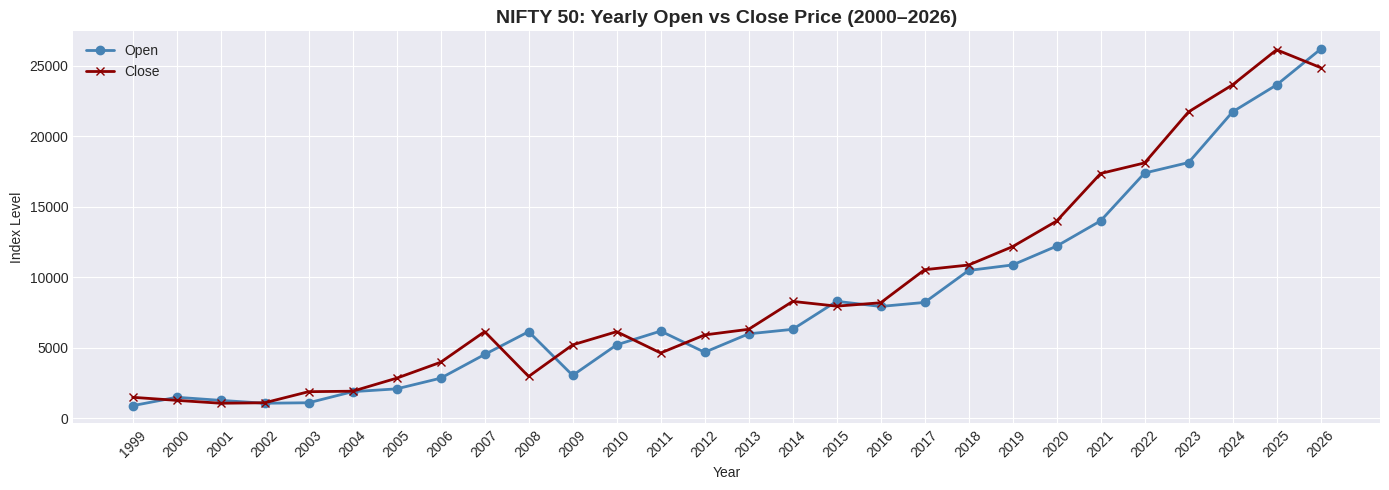

In [65]:
# Yearly aggregation

yearly = full_nifty_df.groupby(full_nifty_df.index.year).agg(
    Year_Open  = ('Open',  'first'),
    Year_Close = ('Close', 'last'),
    Year_High  = ('High',  'max'),
    Year_Low   = ('Low',   'min'),
    Avg_Volume = ('Volume','mean')
).reset_index()


yearly.rename(columns={'Date': 'Year'}, inplace=True) #renaming date to year

# Plot
plt.figure(figsize=(14, 5))
plt.plot(yearly['Year'], yearly['Year_Open'],  label='Open',  marker='o', color='steelblue', linewidth=2)
plt.plot(yearly['Year'], yearly['Year_Close'], label='Close', marker='x', color='darkred',   linewidth=2)

plt.title('NIFTY 50: Yearly Open vs Close Price (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Index Level')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

* Historically the opening and closing prices have evolved higher

*Feature engineering of annual return percentage, candle stick strength and the difference between them*

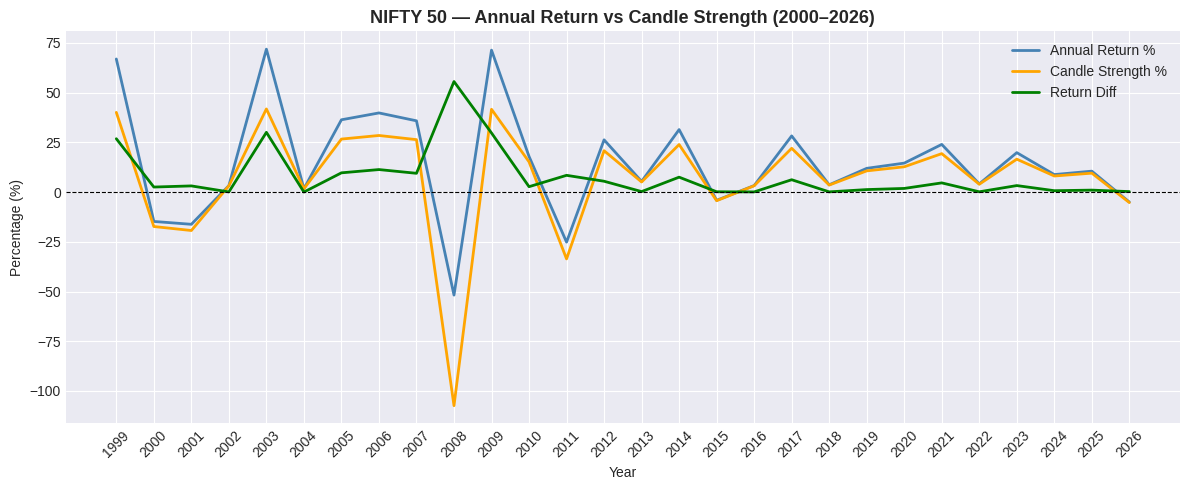

In [66]:
# Feature engineering
yearly['Annual_Return_%']   = (yearly['Year_Close'] - yearly['Year_Open']) / yearly['Year_Open']  * 100
yearly['Candle_Strength_%'] = (yearly['Year_Close'] - yearly['Year_Open']) / yearly['Year_Close'] * 100
yearly['Return_Diff']       = yearly['Annual_Return_%'] - yearly['Candle_Strength_%']

# Plot — fix x-axis by passing yearly['Year']
plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Annual_Return_%'],   label='Annual Return %',    color='steelblue', linewidth=2)
plt.plot(yearly['Year'], yearly['Candle_Strength_%'], label='Candle Strength %',  color='orange',    linewidth=2)
plt.plot(yearly['Year'], yearly['Return_Diff'],       label='Return Diff',        color='green',     linewidth=2)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 — Annual Return vs Candle Strength (2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
distorted = yearly[abs(yearly['Candle_Strength_%']) - abs(yearly['Annual_Return_%']) > 10]
print(distorted[['Year', 'Annual_Return_%', 'Candle_Strength_%', 'Return_Diff']])

   Year  Annual_Return_%  Candle_Strength_%  Return_Diff
9  2008       -51.779852        -107.382194    55.602342


* Annual return % and candle stregth % moves in the same direction while the return difference is not

* During markest crashes, the candle strength % falls more than the annual return %

* So candle strength % may be more volatile to market crashes than annual return %

* Divergence is greater for year 2008

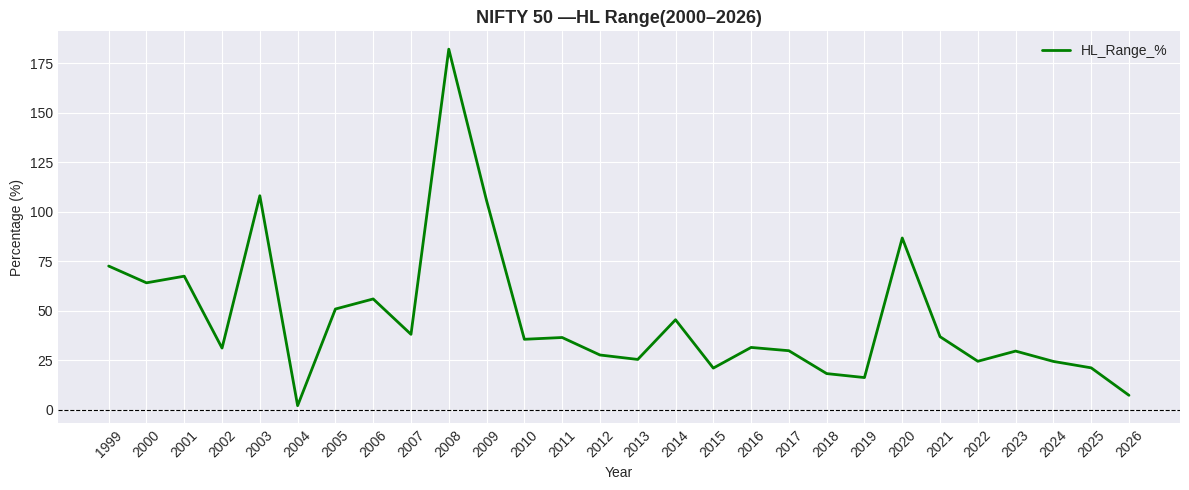

In [76]:
yearly['HL_Range_%'] = (yearly['Year_High'] - yearly['Year_Low']) / yearly['Year_Low'] * 100


plt.figure(figsize=(12, 5))

plt.plot(yearly['Year'], yearly['HL_Range_%'],       label='HL_Range_%',        color='green',     linewidth=2)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 —HL Range(2000–2026)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

* Volatility was higher in 2003, 2008, 2020

* 2004 has nearly zero volatility

In [77]:

yearly['Prev_HL_Range_%'] = yearly['HL_Range_%'].shift(1)

In [78]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               28 non-null     int32  
 1   Year_Open          28 non-null     float64
 2   Year_Close         28 non-null     float64
 3   Year_High          28 non-null     float64
 4   Year_Low           28 non-null     float64
 5   Avg_Volume         28 non-null     float64
 6   Annual_Return_%    28 non-null     float64
 7   Candle_Strength_%  28 non-null     float64
 8   Return_Diff        28 non-null     float64
 9   HL_Range_%         28 non-null     float64
 10  Prev_HL_Range_%    27 non-null     float64
dtypes: float64(10), int32(1)
memory usage: 2.4 KB


In [79]:
yearly.dropna(inplace=True)

In [80]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 1 to 27
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               27 non-null     int32  
 1   Year_Open          27 non-null     float64
 2   Year_Close         27 non-null     float64
 3   Year_High          27 non-null     float64
 4   Year_Low           27 non-null     float64
 5   Avg_Volume         27 non-null     float64
 6   Annual_Return_%    27 non-null     float64
 7   Candle_Strength_%  27 non-null     float64
 8   Return_Diff        27 non-null     float64
 9   HL_Range_%         27 non-null     float64
 10  Prev_HL_Range_%    27 non-null     float64
dtypes: float64(10), int32(1)
memory usage: 2.4 KB


*feature engineering the recovery rate*

In [81]:
yearly['Recovery_Rate_%'] = (
    (yearly['Year_Close'] - yearly['Year_Low']) /
    (yearly['Year_High'] - yearly['Year_Low'])
) * 100


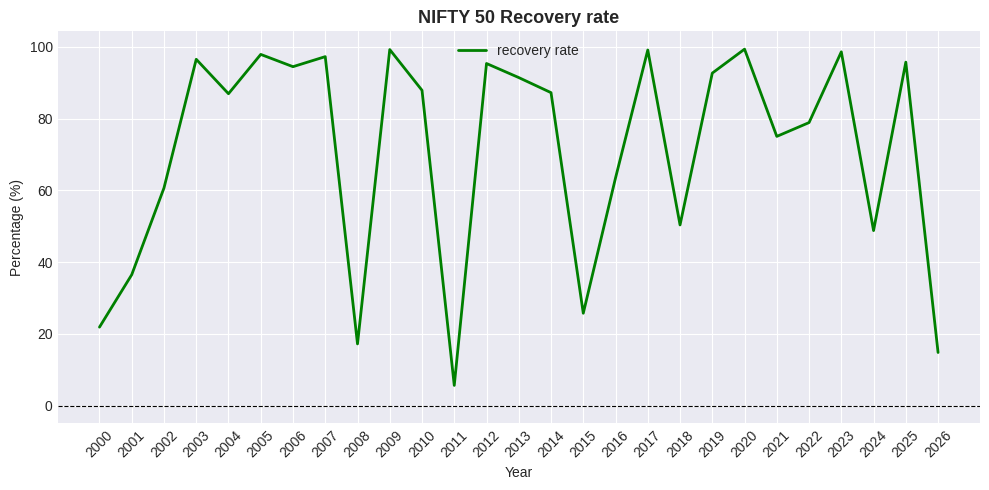

In [85]:

plt.figure(figsize=(10,5))
plt.plot(yearly['Year'], yearly['Recovery_Rate_%'],label='recovery rate',color='green', linewidth=2)


plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('NIFTY 50 Recovery rate', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.xticks(yearly['Year'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# 2. ANNUAL RETURNS (Bar Chart)
plt.figure(figsize=figsize)
yearly['Return'] = yearly['Close'].pct_change() * 100
colors = ['green' if x > 0 else 'red' for x in yearly['Return']]
plt.bar(yearly.index, yearly['Return'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
plt.title('NIFTY 50 Annual Returns %', fontsize=16, fontweight='bold')
plt.ylabel('Annual Return %')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

KeyError: 'Close'

<Figure size 1000x500 with 0 Axes>

In [ ]:
# 3. HIGH-LOW RANGE (Volatility)
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly['High'], label='High', color='orange', linewidth=2)
plt.plot(yearly.index, yearly['Low'], label='Low', color='purple', linewidth=2)
plt.fill_between(yearly.index, yearly['High'], yearly['Low'], alpha=0.3, color='gray', label='Trading Range')
plt.title('NIFTY 50 Yearly High-Low Range', fontsize=16, fontweight='bold')
plt.ylabel('Index Level')
plt.xlabel('Year')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 4. VOLUME TREND
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly['Volume'], color='darkgreen', linewidth=3, marker='o', markersize=6)
plt.title('NIFTY 50 Average Trading Volume', fontsize=16, fontweight='bold')
plt.ylabel('Avg Volume')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(yearly.index, np.log(yearly['Close']), color='darkblue', linewidth=3, marker='s', markersize=5)
plt.title('NIFTY 50 Log-Scale Price (Smooth Growth)', fontsize=16, fontweight='bold')
plt.ylabel('Log(Close Price)')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
cum_returns = (1 + yearly['Return']/100).cumprod() - 1
plt.plot(yearly.index, cum_returns * 100, color='gold', linewidth=4, marker='D', markersize=6)
plt.title('NIFTY 50 Cumulative Returns (₹100 → ?)', fontsize=16, fontweight='bold')
plt.ylabel('Cumulative Return %')
plt.xlabel('Year')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("📊 NIFTY 50 25-YEAR ANALYSIS")
print(f"Period: {yearly.index[0]}-{yearly.index[-1]} ({len(yearly)} years)")
print(f"CAGR: {((yearly['Close'].iloc[-1]/yearly['Close'].iloc[0])**(1/len(yearly))*100-100):.1f}%")
print(f"Best Year: {yearly['Return'].max():.1f}% ({yearly['Return'].idxmax()})")
print(f"Worst Year: {yearly['Return'].min():.1f}% ({yearly['Return'].idxmin()})")
print(f"Total Return: {cum_returns.iloc[-1]*100:.1f}%")